In [1]:
import os
from glob import glob

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.metrics.pairwise import cosine_similarity

from tqdm import tqdm
import re

In [2]:
import warnings
warnings.filterwarnings('ignore')

In [3]:
import re
import unicodedata

# Hebrew cantillation marks (Ta'amei HaMikra)
CANTILLATION_RE = re.compile(r'[\u0591-\u05AF]')

# Hebrew vowel points / diacritics (Niqqud + related marks)
DIACRITICS_RE = re.compile(r'[\u05B0-\u05BC\u05BD\u05BF\u05C1\u05C2\u05C7]')


def clean_hebrew_text(
    text,
    remove_cantillation=True,
    remove_diacritics=False,
    normalize=True
):
    """
    Clean Hebrew Biblical text by optionally removing cantillation
    and/or vowel diacritics.

    Parameters
    ----------
    text : str
        Hebrew text to clean.

    remove_cantillation : bool
        Remove cantillation marks (טעמים).

    remove_diacritics : bool
        Remove vowel points / niqqud.

    normalize : bool
        Apply Unicode NFC normalization before processing.

    Returns
    -------
    str
        Cleaned Hebrew text.
    """

    if normalize:
        text = unicodedata.normalize("NFC", text)

    if remove_cantillation:
        text = CANTILLATION_RE.sub('', text)

    if remove_diacritics:
        text = DIACRITICS_RE.sub('', text)

    return text

In [4]:
file_path = r'/Users/aaronadair/Downloads/DiachronicEmb-BigHistData-main/test/all_together.txt'  # Replace with the actual path to your text file

with open(file_path, 'r', encoding='utf-8') as file:
    lines = file.readlines()

In [5]:
# Optional: Remove newline characters from each line
heb_text = [line.strip() for line in lines]

heb_text[:10]

['\u202axxxx    Unicode/XML Leningrad Codex [UXLC 2.4]\u202c',
 '\u202axxxx    Build: 27.5    -    13 Oct 2025  06:35\u202c',
 '\u202axxxx    Layout: Full; Content: Accents.\u202c',
 '\u202axxxx\u202c',
 '\u202axxxx    Jeremiah (52 chapters, 1364 verses).\u202c',
 '\u202axxxx\u202c',
 '\u202axxxx    Chapter 1   (19 verses)\u202c',
 '\u202axxxx\u202c',
 '\u202b\xa01\xa0\xa0׃1\xa0\xa0\xa0דִּבְרֵ֥י יִרְמְיָ֖הוּ בֶּן־חִלְקִיָּ֑הוּ מִן־הַכֹּֽהֲנִים֙ אֲשֶׁ֣ר בַּעֲנָת֔וֹת בְּאֶ֖רֶץ בִּנְיָמִֽן׃ \u202c',
 '\u202b\xa02\xa0\xa0׃1\xa0\xa0\xa0אֲשֶׁ֨ר הָיָ֤ה דְבַר־יְהוָה֙ אֵלָ֔יו בִּימֵ֛י יֹאשִׁיָּ֥הוּ בֶן־אָמ֖וֹן מֶ֣לֶךְ יְהוּדָ֑ה בִּשְׁלֹשׁ־עֶשְׂרֵ֥ה שָׁנָ֖ה לְמָלְכֽוֹ׃ \u202c']

In [6]:
heb_text[:100]

['\u202axxxx    Unicode/XML Leningrad Codex [UXLC 2.4]\u202c',
 '\u202axxxx    Build: 27.5    -    13 Oct 2025  06:35\u202c',
 '\u202axxxx    Layout: Full; Content: Accents.\u202c',
 '\u202axxxx\u202c',
 '\u202axxxx    Jeremiah (52 chapters, 1364 verses).\u202c',
 '\u202axxxx\u202c',
 '\u202axxxx    Chapter 1   (19 verses)\u202c',
 '\u202axxxx\u202c',
 '\u202b\xa01\xa0\xa0׃1\xa0\xa0\xa0דִּבְרֵ֥י יִרְמְיָ֖הוּ בֶּן־חִלְקִיָּ֑הוּ מִן־הַכֹּֽהֲנִים֙ אֲשֶׁ֣ר בַּעֲנָת֔וֹת בְּאֶ֖רֶץ בִּנְיָמִֽן׃ \u202c',
 '\u202b\xa02\xa0\xa0׃1\xa0\xa0\xa0אֲשֶׁ֨ר הָיָ֤ה דְבַר־יְהוָה֙ אֵלָ֔יו בִּימֵ֛י יֹאשִׁיָּ֥הוּ בֶן־אָמ֖וֹן מֶ֣לֶךְ יְהוּדָ֑ה בִּשְׁלֹשׁ־עֶשְׂרֵ֥ה שָׁנָ֖ה לְמָלְכֽוֹ׃ \u202c',
 '\u202b\xa03\xa0\xa0׃1\xa0\xa0\xa0וַיְהִ֗י בִּימֵ֨י יְהוֹיָקִ֤ים בֶּן־יֹאשִׁיָּ֙הוּ֙ מֶ֣לֶךְ יְהוּדָ֔ה עַד־תֹּם֙ עַשְׁתֵּ֣י עֶשְׂרֵ֣ה שָׁנָ֔ה לְצִדְקִיָּ֥הוּ בֶן־יֹאשִׁיָּ֖הוּ מֶ֣לֶךְ יְהוּדָ֑ה עַד־גְּל֥וֹת יְרוּשָׁלַ֖͏ִם בַּחֹ֥דֶשׁ הַחֲמִישִֽׁי׃ ס \u202c',
 '\u202b\xa04\xa0\xa0׃1\xa0\xa0\xa0וַיְהִ֥י דְבַר־יְהוָ֖ה אֵלַ֥י

In [7]:
heb_text[6].split("\xa0")[-1]

'\u202axxxx    Chapter 1   (19 verses)\u202c'

In [8]:
heb_text[8].split("\xa0")[-1].split("\u202c")[0].strip()

'דִּבְרֵ֥י יִרְמְיָ֖הוּ בֶּן־חִלְקִיָּ֑הוּ מִן־הַכֹּֽהֲנִים֙ אֲשֶׁ֣ר בַּעֲנָת֔וֹת בְּאֶ֖רֶץ בִּנְיָמִֽן׃'

In [9]:
def clean_line(heb_line):
    temp_line = heb_line
    temp_line = re.sub("[\(\[].*?[\)\]]", "", temp_line)
    # if "\xa0" in temp_line:
    #     temp_line = temp_line.split("\xa0")[-1].split("\u202c")[0].strip()
    #     temp_line = temp_line.replace("*", "")
    #     return temp_line
    # else:
    #     return ""

    if "\xa0" in temp_line:

        temp_line = temp_line.split("\xa0")[-1]

    if "\u202c" in temp_line:

        temp_line = temp_line.split("\u202c")[0].strip()

    # NEW: clean Hebrew marks

    temp_line = clean_hebrew_text(
        temp_line,
        remove_cantillation=True,
        remove_diacritics=False
    )

    return temp_line.strip()

In [10]:
cleaned_test_list = []

for i, line in enumerate(heb_text[:]):
    #print(i, clean_line(line))
    cleaned_test_list.append(clean_line(line))

In [11]:
heb_text[74]

'\u202b\xa05\xa0\xa0׃3\xa0\xa0\xa0הֲיִנְטֹ֣ר לְעוֹלָ֔ם אִם־יִשְׁמֹ֖ר לָנֶ֑צַח הִנֵּ֥ה *דברתי\u202a[t]\u202c\u202a[y]\u202c **דִבַּ֛רְתְּ וַתַּעֲשִׂ֥י הָרָע֖וֹת וַתּוּכָֽל׃ פ \u202c'

In [12]:
b'\u202a\u202c\u202a\u202c'.decode("utf-8")

'\\u202a\\u202c\\u202a\\u202c'

In [13]:
cleaned_test_list = [x for x in cleaned_test_list if x != ""]

In [14]:
len(cleaned_test_list)

29034

In [15]:
np.sum([len(s.split()) for s in cleaned_test_list])

277112

In [16]:
# with open('/Users/aaronadair/Downloads/DiachronicEmb-BigHistData-main/all_together.txt', 'w') as outfile:
#     for fname in filenames:
#         with open(fname) as infile:
#             for line in infile:
#                 outfile.write(line)

## List of Books in Classical Biblical Hebrew (CBH)

Genesis, Exodus, Leviticus, Numbers, Deuteronomy, Joshua, Judges, 1 Samuel, 2 Samuel, 1 Kings, 2 Kings

In [17]:
cbh_list = ['Genesis', 'Exodus', 'Leviticus', 'Numbers', 'Deuteronomy', 'Joshua', 'Judges', 'Samuel_1', 'Samuel_2', 'Kings_1', 'Kings_2']

filenames = glob(r'/Users/aaronadair/Downloads/DiachronicEmb-BigHistData-main/test/*.txt')
with open('/Users/aaronadair/Downloads/DiachronicEmb-BigHistData-main/cbh.txt', 'w') as outfile:
    for fname in filenames:
        if fname.split('/')[-1].split('.')[0] in cbh_list:
            print(fname.split('/')[-1].split('.')[0])
            with open(fname) as infile:
                for line in infile:
                    #line = clean_line(line)
                    outfile.write(line)

Joshua
Exodus
Numbers
Judges
Samuel_1
Samuel_2
Kings_2
Genesis
Kings_1
Deuteronomy
Leviticus


## List of Books in Late Biblical Hebrew (LBH)

Ezra, Nehemiah, 1 Chronicles, 1 Chronicles, Ecclesiastes, Daniel, Esther

In [18]:
lbh_list = ['Ezra', 'Nehemiah', 'Chronicles_1', 'Chronicles_2', 'Ecclesiastes', 'Daniel', 'Esther']

filenames = glob(r'/Users/aaronadair/Downloads/DiachronicEmb-BigHistData-main/test/*.txt')
with open('/Users/aaronadair/Downloads/DiachronicEmb-BigHistData-main/lbh.txt', 'w') as outfile:
    for fname in filenames:
        if fname.split('/')[-1].split('.')[0] in lbh_list:
            print(fname.split('/')[-1].split('.')[0])
            with open(fname) as infile:
                for line in infile:
                    # line = clean_line(line)
                    outfile.write(line)

Ezra
Chronicles_1
Chronicles_2
Nehemiah
Esther
Daniel
Ecclesiastes


In [19]:
import collections
import string

def count_words_in_file(filepath):
    """Counts the occurrences of each word in a text file."""
    word_counts = collections.Counter()

    try:
        with open(filepath, 'r', encoding='utf-8') as file:
            text = file.read()

            # Preprocess: convert to lowercase and remove punctuation
            text = text.lower()
            text = text.translate(str.maketrans('', '', string.punctuation))

            words = text.split()
            word_counts.update(words)

        return word_counts

    except FileNotFoundError:
        print(f"Error: The file '{filepath}' was not found.")
        return None

In [20]:
lbh_counter = count_words_in_file('/Users/aaronadair/Downloads/DiachronicEmb-BigHistData-main/lbh.txt')
lbh_counter

Counter({'\u202b': 3196,
         '\u202c': 3196,
         'ס': 494,
         '׀': 284,
         '׃2': 260,
         '\u202axxxx\u202c': 258,
         'פ': 246,
         '׃7': 229,
         '׃6': 204,
         '׃9': 204,
         '׃4': 174,
         '׃8': 173,
         '׃3': 162,
         '׃10': 161,
         '׃11': 161,
         '׃1': 155,
         '׃5': 154,
         '\u202axxxx': 151,
         'אֲשֶׁ֣ר': 148,
         '10': 132,
         '1': 131,
         '2': 131,
         '׃12': 131,
         '3': 130,
         'verses\u202c': 129,
         '8': 129,
         '4': 128,
         '5': 128,
         '6': 128,
         '7': 128,
         '9': 128,
         '13': 126,
         '11': 125,
         '12': 125,
         'chapter': 122,
         'אֲשֶׁ֥ר': 122,
         '14': 120,
         'בְּנֵ֣י': 119,
         '17': 111,
         'כִּ֣י': 110,
         '15': 106,
         '16': 103,
         '18': 96,
         '19': 94,
         '20': 81,
         'בְּנֵ֥י': 80,
         '21': 80,
    

In [21]:
cbh_counter = count_words_in_file('/Users/aaronadair/Downloads/DiachronicEmb-BigHistData-main/cbh.txt')
cbh_counter

Counter({'\u202b': 10171,
         '\u202c': 10171,
         '׀': 846,
         'ס': 753,
         '\u202axxxx\u202c': 690,
         'פ': 626,
         'אֲשֶׁ֣ר': 609,
         'אֲשֶׁ֥ר': 587,
         'יְהוָ֖ה': 417,
         '\u202axxxx': 379,
         '׃7': 374,
         '׃15': 372,
         'כִּ֣י': 371,
         '׃14': 366,
         'וַיֹּ֣אמֶר': 362,
         '13': 351,
         '׃1': 350,
         '׃19': 350,
         '1': 349,
         '2': 349,
         '׃18': 348,
         '8': 346,
         'verses\u202c': 345,
         '3': 345,
         '4': 345,
         '5': 345,
         '6': 345,
         '7': 345,
         '9': 345,
         '10': 345,
         '12': 344,
         '11': 342,
         '׃22': 339,
         '׃8': 337,
         '15': 336,
         '׃4': 336,
         '16': 335,
         'chapter': 334,
         '14': 332,
         '׃13': 330,
         '׃9': 329,
         '17': 326,
         '18': 325,
         '׃11': 324,
         'אֲשֶׁ֨ר': 323,
         '׃2': 323,
     

In [22]:
sum(cbh_counter.values()), sum(lbh_counter.values())

(173575, 54194)

In [23]:
sum(cbh_counter.values()) / (sum(cbh_counter.values()) + sum(lbh_counter.values())), sum(lbh_counter.values()) / (sum(cbh_counter.values()) + sum(lbh_counter.values()))

(0.7620659527854976, 0.23793404721450243)

In [24]:
sum(cbh_counter.values()) / sum(lbh_counter.values())

3.2028453334317453

In [25]:
for item, count in cbh_counter.items():
    if count < 100:
        continue
    print(item, count / sum(cbh_counter.values()))
    

‪xxxx 0.0021834941667866915
13 0.002022180613567622
‪xxxx‬ 0.003975226847184214
24 0.0014921503672763936
verses‬ 0.001987613423592107
chapter 0.0019242402419703299
1 0.002010658216909117
18 0.0018723894570070575
‫ 0.05859714820682702
׃1 0.0020164194152383695
יְהוָ֑ה 0.0011983292524845167
וַיֹּ֤אמֶר 0.0016361803255077055
יְהוָה֙ 0.0016188967305199482
‬ 0.05859714820682702
2 0.002010658216909117
יִשְׂרָאֵֽל׃ 0.0009563589226559124
3 0.001987613423592107
אֲשֶׁ֨ר 0.0018608670603485525
4 0.001987613423592107
5 0.001987613423592107
לֹ֥א 0.0018378222670315425
וְלֹ֥א 0.0011003888808872246
6 0.001987613423592107
כִּ֣י 0.002137404580152672
7 0.001987613423592107
אֲשֶׁ֤ר 0.0008468961544001152
אֲשֶׁ֥ר 0.0033818234192712084
8 0.0019933746219213595
9 0.001987613423592107
כִּ֤י 0.0007028661961688031
יְהוָ֣ה 0.000985164914302175
פ 0.0036065101541120554
10 0.001987613423592107
11 0.00197032982860435
׀ 0.0048739737865476015
לֵאמֹ֔ר 0.0009045081376926401
ס 0.004338182341927121
12 0.0019818522252628545
לֵא

In [26]:
for item, count in lbh_counter.items():
    if count < 30:
        continue
    print(item, count / sum(lbh_counter.values()))

‪xxxx 0.002786286304756984
13 0.002324980625161457
‪xxxx‬ 0.004760674613425841
10 0.0024356939882643836
verses‬ 0.0023803373067129204
chapter 0.0022511717164261725
1 0.0024172417610805624
11 0.002306528397977636
‫ 0.058973318079492194
׃1 0.0028600952134922686
מֶ֣לֶךְ 0.0010333247222939809
‬ 0.058973318079492194
2 0.0024172417610805624
יְהוָ֖ה 0.00101487249511016
אֱלֹהֵ֣י 0.0006827324058013803
אֲשֶׁ֥ר 0.0022511717164261725
3 0.002398789533896741
אֲשֶׁ֣ר 0.002730929623205521
יְהוָה֙ 0.0008118979960881278
יִשְׂרָאֵ֔ל 0.0009226113591910543
4 0.0023618850795290992
5 0.0023618850795290992
6 0.0023618850795290992
ס 0.009115400228807618
7 0.0023618850795290992
אֲשֶׁ֨ר 0.0011255858582130862
8 0.0023803373067129204
9 0.0023618850795290992
מֵא֖וֹת 0.0011440380853969074
פ 0.004539247887219987
׃2 0.004797579067793482
׀ 0.0052404325202051886
בְּנֵ֣י 0.0021958150348747093
יִשְׂרָאֵֽל׃ 0.0006642801786175592
עָשָֽׂר׃ 0.0007011846329852014
עֶשְׂרִ֥ים 0.0008118979960881278
12 0.002306528397977636
14 0.00

In [27]:
cbh_counter.most_common(10)

[('\u202b', 10171),
 ('\u202c', 10171),
 ('׀', 846),
 ('ס', 753),
 ('\u202axxxx\u202c', 690),
 ('פ', 626),
 ('אֲשֶׁ֣ר', 609),
 ('אֲשֶׁ֥ר', 587),
 ('יְהוָ֖ה', 417),
 ('\u202axxxx', 379)]

In [28]:
lbh_counter.most_common(10)

[('\u202b', 3196),
 ('\u202c', 3196),
 ('ס', 494),
 ('׀', 284),
 ('׃2', 260),
 ('\u202axxxx\u202c', 258),
 ('פ', 246),
 ('׃7', 229),
 ('׃6', 204),
 ('׃9', 204)]

In [29]:
cbh_counter.most_common(10)[0][1]

10171

In [30]:
lbh_index_list = []
lbh_val_list = []
cbh_index_list = []
cbh_val_list = []

for i, val in enumerate(cbh_counter.most_common(100000)):
    cbh_index_list.append((i+1))
    cbh_val_list.append(val[1])

for i, val in enumerate(lbh_counter.most_common(100000)):
    lbh_index_list.append((i+1))
    lbh_val_list.append(val[1])


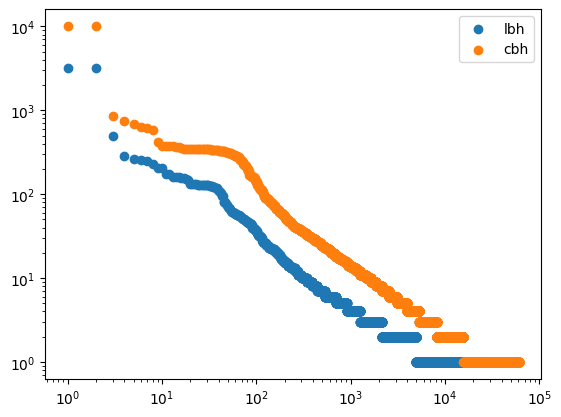

In [31]:
plt.scatter(lbh_index_list, lbh_val_list, label='lbh')
plt.scatter(cbh_index_list, cbh_val_list, label='cbh')

plt.legend()
plt.xscale('log')
plt.yscale('log')

In [32]:
len(cbh_index_list)

60477

In [33]:
list(map(lambda x, y: x / y, lbh_val_list, lbh_index_list))

[3196.0,
 1598.0,
 164.66666666666666,
 71.0,
 52.0,
 43.0,
 35.142857142857146,
 28.625,
 22.666666666666668,
 20.4,
 15.818181818181818,
 14.416666666666666,
 12.461538461538462,
 11.5,
 10.733333333333333,
 9.6875,
 9.058823529411764,
 8.38888888888889,
 7.7894736842105265,
 6.6,
 6.238095238095238,
 5.954545454545454,
 5.695652173913044,
 5.416666666666667,
 5.16,
 4.961538461538462,
 4.7407407407407405,
 4.571428571428571,
 4.413793103448276,
 4.266666666666667,
 4.129032258064516,
 3.9375,
 3.787878787878788,
 3.676470588235294,
 3.4857142857142858,
 3.388888888888889,
 3.2432432432432434,
 3.1315789473684212,
 2.8461538461538463,
 2.75,
 2.5853658536585367,
 2.4523809523809526,
 2.2325581395348837,
 2.1363636363636362,
 1.8,
 1.7391304347826086,
 1.702127659574468,
 1.6041666666666667,
 1.530612244897959,
 1.4,
 1.3333333333333333,
 1.3076923076923077,
 1.2452830188679245,
 1.1666666666666667,
 1.1272727272727272,
 1.1071428571428572,
 1.0701754385964912,
 1.0172413793103448,
 1

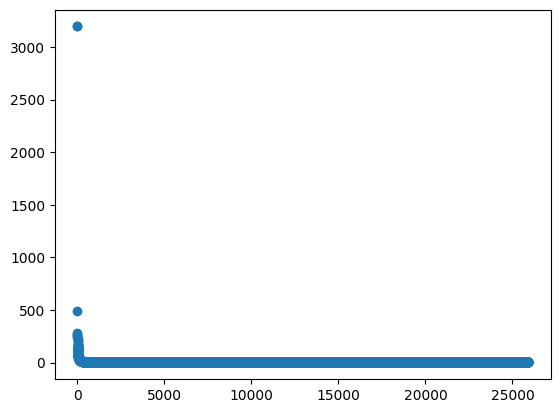

In [34]:
plt.scatter(lbh_index_list, lbh_val_list)

In [35]:
import powerlaw

In [36]:
fit = powerlaw.Fit(lbh_val_list)

# Print the fitted alpha and xmin
print(f"Fitted alpha: {fit.power_law.alpha:.2f}")
print(f"Fitted xmin: {fit.power_law.xmin:.2f}")

Calculating best minimal value for power law fit
Fitted alpha: 2.45
Fitted xmin: 4.00


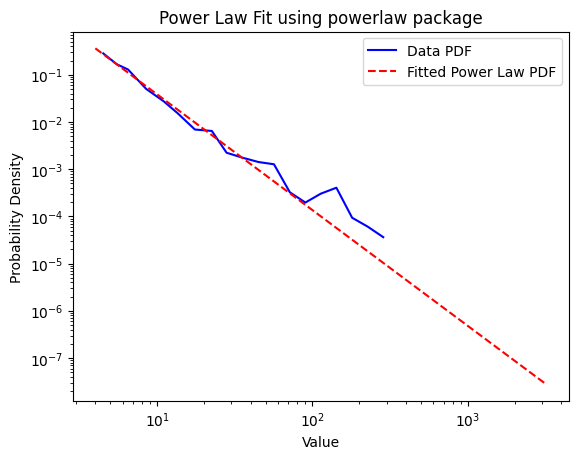

In [37]:
# Plot the fitted power law PDF against the data PDF
fig, ax = plt.subplots()
fit.plot_pdf(ax=ax, color='b', label='Data PDF')
fit.power_law.plot_pdf(ax=ax, color='r', linestyle='--', label='Fitted Power Law PDF')
plt.xlabel('Value')
plt.ylabel('Probability Density')
plt.title('Power Law Fit using powerlaw package')
plt.legend()
plt.show()

In [38]:
fit.power_law.sigma

0.04071785073526111

In [39]:
from scipy.optimize import curve_fit

In [40]:
# Define the power law function to fit
def power_law_func(x, a, b):
    return a * x**b

# Fit the curve
popt, pcov = curve_fit(power_law_func, cbh_index_list, cbh_val_list, p0=[-1, 1])

# Extract the fitted parameters
a_fit, b_fit = popt

# Print the fitted parameters
print(f"Fitted a: {a_fit:.2f}")
print(f"Fitted b: {b_fit:.2f}")

Fitted a: 11107.12
Fitted b: -1.14


In [41]:
# cleaned_test_list = []

# for i, line in enumerate(heb_text[:]):
#     #print(i, clean_line(line))
#     cleaned_test_list.append(clean_line(line))

h_counter = count_words_in_file('/Users/aaronadair/Downloads/DiachronicEmb-BigHistData-main/test/all_together.txt')

index_list = []
val_list = []

for i, val in enumerate(h_counter.most_common(1000000)):
    index_list.append((i+1))
    val_list.append(val[1])

In [42]:
len(index_list)

126850

In [43]:
popt, pcov = curve_fit(power_law_func, index_list, val_list, p0=[-1, 1])

# Extract the fitted parameters
a_fit, b_fit = popt

# Print the fitted parameters
print(f"Fitted a: {a_fit:.2f}")
print(f"Fitted b: {b_fit:.2f}")

Fitted a: 25602.62
Fitted b: -1.10


In [44]:
popt, pcov = curve_fit(power_law_func, index_list[100:10000], val_list[100:10000], p0=[-1, 1])

# Extract the fitted parameters
a_fit, b_fit = popt

# Print the fitted parameters
print(f"Fitted a: {a_fit:.2f}")
print(f"Fitted b: {b_fit:.2f}")

Fitted a: 14026.25
Fitted b: -0.92


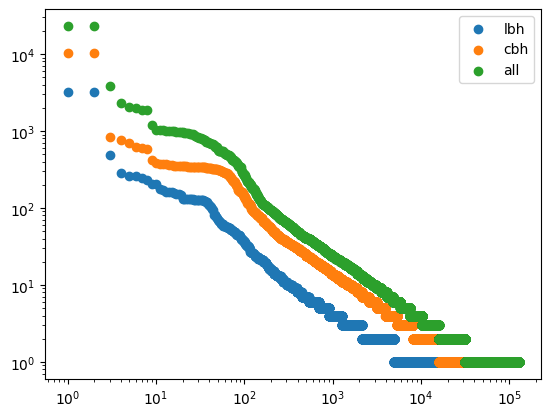

In [45]:
plt.scatter(lbh_index_list, lbh_val_list, label='lbh')
plt.scatter(cbh_index_list, cbh_val_list, label='cbh')
plt.scatter(index_list, val_list, label='all')

plt.legend()
plt.xscale('log')
plt.yscale('log')

<Axes: xlabel='Rank', ylabel='Count'>

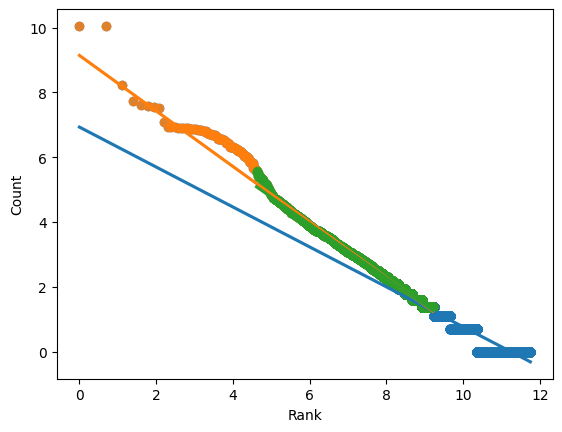

In [46]:
data = list(zip(index_list, val_list))
column_names = ['Rank', 'Count']

# Create the DataFrame
count_rank_df = pd.DataFrame(data, columns=column_names)
count_rank_df['Rank'] = count_rank_df['Rank'].apply(lambda x: np.log(x))
count_rank_df['Count'] = count_rank_df['Count'].apply(lambda x: np.log(x))


sns.regplot(count_rank_df, x='Rank', y='Count', x_ci='ci')
sns.regplot(count_rank_df[:10000], x='Rank', y='Count', x_ci='ci')
sns.regplot(count_rank_df[100:10000], x='Rank', y='Count', x_ci='ci')

In [47]:
slope, intercept, r_value, p_value, std_err = stats.linregress(count_rank_df['Rank'][100:10000], count_rank_df['Count'][100:10000])

# Format the equation string
equation = f'y = {intercept:.2f} + {slope:.2f}x'

equation

'y = 8.92 + -0.83x'

In [48]:
slope, intercept, r_value, p_value, std_err = stats.linregress(count_rank_df['Rank'][:10000], count_rank_df['Count'][:10000])

# Format the equation string
equation = f'y = {intercept:.2f} + {slope:.2f}x'

equation

'y = 9.14 + -0.86x'

## Making Gensim Models

In [49]:
import gensim
from gensim import corpora, models
from gensim.utils import simple_preprocess
from gensim.models.callbacks import CallbackAny2Vec

In [50]:
filepath = r'/Users/aaronadair/Downloads/DiachronicEmb-BigHistData-main/test/all_together.txt'
#filepath = r'/Users/aaronadair/Downloads/DiachronicEmb-BigHistData-main/cbh.txt'


with open(filepath, 'r', encoding='utf-8') as file:
    lines = file.readlines()

In [51]:
len(lines)

29034

In [52]:
heb_text = [clean_line(line) for line in lines]
heb_text = [x for x in heb_text if x != '']

In [53]:
texts = [[text for text in doc.split()] for doc in heb_text]

In [54]:
texts

[['\u202axxxx', 'Unicode/XML', 'Leningrad', 'Codex'],
 ['\u202axxxx', 'Build:', '27.5', '-', '13', 'Oct', '2025', '06:35'],
 ['\u202axxxx', 'Layout:', 'Full;', 'Content:', 'Accents.'],
 ['\u202axxxx'],
 ['\u202axxxx', 'Jeremiah', '.'],
 ['\u202axxxx'],
 ['\u202axxxx', 'Chapter', '1'],
 ['\u202axxxx'],
 ['דִּבְרֵי',
  'יִרְמְיָהוּ',
  'בֶּן־חִלְקִיָּהוּ',
  'מִן־הַכֹּֽהֲנִים',
  'אֲשֶׁר',
  'בַּעֲנָתוֹת',
  'בְּאֶרֶץ',
  'בִּנְיָמִֽן׃'],
 ['אֲשֶׁר',
  'הָיָה',
  'דְבַר־יְהוָה',
  'אֵלָיו',
  'בִּימֵי',
  'יֹאשִׁיָּהוּ',
  'בֶן־אָמוֹן',
  'מֶלֶךְ',
  'יְהוּדָה',
  'בִּשְׁלֹשׁ־עֶשְׂרֵה',
  'שָׁנָה',
  'לְמָלְכֽוֹ׃'],
 ['וַיְהִי',
  'בִּימֵי',
  'יְהוֹיָקִים',
  'בֶּן־יֹאשִׁיָּהוּ',
  'מֶלֶךְ',
  'יְהוּדָה',
  'עַד־תֹּם',
  'עַשְׁתֵּי',
  'עֶשְׂרֵה',
  'שָׁנָה',
  'לְצִדְקִיָּהוּ',
  'בֶן־יֹאשִׁיָּהוּ',
  'מֶלֶךְ',
  'יְהוּדָה',
  'עַד־גְּלוֹת',
  'יְרוּשָׁלַ͏ִם',
  'בַּחֹדֶשׁ',
  'הַחֲמִישִֽׁי׃',
  'ס'],
 ['וַיְהִי', 'דְבַר־יְהוָה', 'אֵלַי', 'לֵאמֹֽר׃'],
 ['בְּטֶרֶם',
  '*אצורך',
  '**אֶצ

In [55]:
dictionary = corpora.Dictionary(texts)

In [56]:
bigram = gensim.models.phrases.Phrases(heb_text, min_count=3, threshold=10)

In [57]:
print(bigram[heb_text][100])

כִּי־כֹה ׀ אָמַר יְהֹוָה לְאִישׁ יְהוּדָה וְלִירוּשָׁלִַם נִירוּ לָכֶם נִיר וְאַֽל־תִּזְרְעוּ אֶל־קוֹצִֽים׃


In [58]:
from gensim.models import Word2Vec

model = Word2Vec(
    texts,
    vector_size=1000,  # Dimensionality of the word vectors
    window=15,         # Context window size
    min_count=1,      # Ignore words with frequency less than 1
    sg=1,             # CBOW (0) or Skip-Gram (1)
    workers=4,        # Number of worker threads
    epochs=100,         # Number of training epochs
    compute_loss=True
)

Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'


In [59]:
len(model.wv.key_to_index)

78214

In [61]:
model.wv.most_similar(positive='טוֹב')

[('וְדוּמָם', 0.6258301138877869),
 ('לִתְשׁוּעַת', 0.6140515804290771),
 ('וְיָחִיל', 0.6098005175590515),
 ('בִּרְכוֹת', 0.5910110473632812),
 ('כִּֽי־תְקַדְּמֶנּוּ', 0.5871641635894775),
 ('כִּֽי־יִשָּׂא', 0.578096330165863),
 ('מִשֶׁתִּדּוֹר', 0.5766034126281738),
 ('פָּֽז׃', 0.5747432708740234),
 ('וּמִפָּז', 0.5747092366218567),
 ('וּתְבוּאָתִי', 0.5688999891281128)]

In [62]:
class LossLogger(CallbackAny2Vec):
    """Callback to log and store per-epoch loss."""
    def __init__(self):
        self.epoch = 0
        self.losses = []
        self.cumulative_loss_since_last_call = 0.0

    def on_epoch_end(self, model):
        # Get the current cumulative loss reported by the model
        current_cumulative_loss = model.get_latest_training_loss()
        
        # Calculate the loss for this specific epoch (delta from the previous cumulative loss)
        epoch_loss = current_cumulative_loss - self.cumulative_loss_since_last_call
        self.losses.append(epoch_loss)
        
        # Update the tracker for the next epoch's calculation
        self.cumulative_loss_since_last_call = current_cumulative_loss
        
        print(f'Epoch {self.epoch+1}: Loss {epoch_loss}')
        self.epoch += 1

In [63]:
loss_logger = LossLogger()

model = Word2Vec(
    texts,
    vector_size=1000,  # Dimensionality of the word vectors
    window=15,         # Context window size
    min_count=1,      # Ignore words with frequency less than 1
    sg=1,             # CBOW (0) or Skip-Gram (1)
    workers=8,        # Number of worker threads
    epochs=100,         # Number of training epochs
    compute_loss=True, 
    callbacks=[loss_logger]
)

Epoch 1: Loss 1175367.375
Epoch 2: Loss 915964.0


Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'


Epoch 3: Loss 828803.625
Epoch 4: Loss 785750.25
Epoch 5: Loss 689223.75
Epoch 6: Loss 593036.0
Epoch 7: Loss 561677.5
Epoch 8: Loss 504363.5
Epoch 9: Loss 480290.5
Epoch 10: Loss 457779.5
Epoch 11: Loss 418011.0
Epoch 12: Loss 390739.5
Epoch 13: Loss 327777.0


Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'


Epoch 14: Loss 317135.5
Epoch 15: Loss 255827.0
Epoch 16: Loss 236791.0
Epoch 17: Loss 217358.0
Epoch 18: Loss 207063.0
Epoch 19: Loss 181810.0
Epoch 20: Loss 178658.0
Epoch 21: Loss 170370.0
Epoch 22: Loss 147512.0
Epoch 23: Loss 153531.0
Epoch 24: Loss 152772.0
Epoch 25: Loss 151342.0
Epoch 26: Loss 146958.0
Epoch 27: Loss 139780.0
Epoch 28: Loss 124392.0
Epoch 29: Loss 139009.0
Epoch 30: Loss 137461.0
Epoch 31: Loss 123074.0
Epoch 32: Loss 109045.0
Epoch 33: Loss 129769.0
Epoch 34: Loss 123662.0
Epoch 35: Loss 125586.0
Epoch 36: Loss 125925.0
Epoch 37: Loss 131978.0
Epoch 38: Loss 126326.0
Epoch 39: Loss 127435.0
Epoch 40: Loss 129485.0
Epoch 41: Loss 126411.0
Epoch 42: Loss 112279.0
Epoch 43: Loss 127856.0
Epoch 44: Loss 108656.0
Epoch 45: Loss 124237.0
Epoch 46: Loss 126068.0
Epoch 47: Loss 119787.0
Epoch 48: Loss 128414.0
Epoch 49: Loss 117350.0
Epoch 50: Loss 114979.0
Epoch 51: Loss 112534.0
Epoch 52: Loss 120043.0
Epoch 53: Loss 111692.0
Epoch 54: Loss 120241.0
Epoch 55: Loss 1

Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'


Epoch 58: Loss 121923.0
Epoch 59: Loss 117682.0
Epoch 60: Loss 114674.0
Epoch 61: Loss 117570.0
Epoch 62: Loss 116550.0
Epoch 63: Loss 114513.0
Epoch 64: Loss 119421.0
Epoch 65: Loss 116158.0
Epoch 66: Loss 112190.0
Epoch 67: Loss 115394.0
Epoch 68: Loss 114834.0
Epoch 69: Loss 117837.0
Epoch 70: Loss 101420.0
Epoch 71: Loss 115818.0
Epoch 72: Loss 116262.0
Epoch 73: Loss 115448.0
Epoch 74: Loss 115668.0
Epoch 75: Loss 106407.0
Epoch 76: Loss 102363.0
Epoch 77: Loss 116888.0
Epoch 78: Loss 97632.0
Epoch 79: Loss 88982.0
Epoch 80: Loss 86318.0
Epoch 81: Loss 90078.0
Epoch 82: Loss 79486.0
Epoch 83: Loss 85930.0
Epoch 84: Loss 84456.0
Epoch 85: Loss 82870.0
Epoch 86: Loss 88298.0
Epoch 87: Loss 83436.0
Epoch 88: Loss 83638.0
Epoch 89: Loss 82930.0
Epoch 90: Loss 75654.0
Epoch 91: Loss 85754.0
Epoch 92: Loss 81336.0
Epoch 93: Loss 71596.0
Epoch 94: Loss 84950.0
Epoch 95: Loss 73166.0


Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'


Epoch 96: Loss 80180.0
Epoch 97: Loss 80440.0
Epoch 98: Loss 83622.0
Epoch 99: Loss 76178.0
Epoch 100: Loss 81032.0


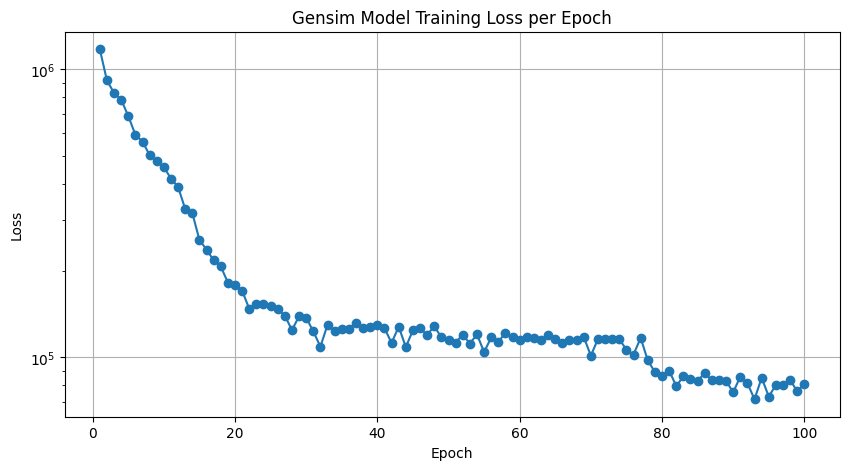

In [64]:
# Plot the loss curve
plt.figure(figsize=(10, 5))
plt.plot(range(1, len(loss_logger.losses) + 1), loss_logger.losses, marker='o')
plt.title('Gensim Model Training Loss per Epoch')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.yscale('log')
plt.grid(True)
plt.show()

In [65]:
# filepath = r'/Users/aaronadair/Downloads/DiachronicEmb-BigHistData-main/test/all_together.txt'
filepath = r'/Users/aaronadair/Downloads/DiachronicEmb-BigHistData-main/lbh.txt'


with open(filepath, 'r', encoding='utf-8') as file:
    lines = file.readlines()

lbh_text = [clean_line(line) for line in lines]
lbh_text = [x for x in lbh_text if x != '']

# texts = [[text for text in doc.split()] for doc in heb_text]

# lbh_text = [clean_line(line) for line in lines]
# lbh_text = lines[0].split(' ')
# lbh_text = [x for x in lbh_text if x != '']

lbh_text = [[text for text in doc.split()] for doc in lbh_text]

In [66]:
len(lbh_text)

3605

In [67]:
loss_logger = LossLogger()

lbh_model = Word2Vec(
    texts,
    vector_size=1000,  # Dimensionality of the word vectors
    window=15,         # Context window size
    min_count=1,      # Ignore words with frequency less than 1
    sg=1,             # CBOW (0) or Skip-Gram (1)
    workers=8,        # Number of worker threads
    epochs=1,         # Number of training epochs
    compute_loss=True, 
    callbacks=[loss_logger]
)

Epoch 1: Loss 1328165.5


Epoch 1: Loss 337184.75
Epoch 2: Loss 284776.875
Epoch 3: Loss 247955.625
Epoch 4: Loss 209561.375
Epoch 5: Loss 197716.375
Epoch 6: Loss 180087.75
Epoch 7: Loss 169554.25
Epoch 8: Loss 161966.25
Epoch 9: Loss 146990.5
Epoch 10: Loss 139437.0


Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'


Epoch 11: Loss 127657.0
Epoch 12: Loss 134092.75
Epoch 13: Loss 114556.25
Epoch 14: Loss 109730.0
Epoch 15: Loss 104614.25


Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'


Epoch 16: Loss 100174.75
Epoch 17: Loss 94132.0
Epoch 18: Loss 102477.75
Epoch 19: Loss 97202.75
Epoch 20: Loss 81507.0
Epoch 21: Loss 78137.25
Epoch 22: Loss 74410.75
Epoch 23: Loss 70750.75
Epoch 24: Loss 67207.25
Epoch 25: Loss 62766.75
Epoch 26: Loss 61365.25
Epoch 27: Loss 59149.75
Epoch 28: Loss 56345.25
Epoch 29: Loss 54863.25
Epoch 30: Loss 52390.75
Epoch 31: Loss 50077.5
Epoch 32: Loss 48829.25
Epoch 33: Loss 44854.25
Epoch 34: Loss 45275.75
Epoch 35: Loss 43951.0
Epoch 36: Loss 42103.5
Epoch 37: Loss 41039.25
Epoch 38: Loss 40680.25
Epoch 39: Loss 39263.5
Epoch 40: Loss 34348.5
Epoch 41: Loss 29613.5
Epoch 42: Loss 28800.0
Epoch 43: Loss 31280.5
Epoch 44: Loss 28185.5
Epoch 45: Loss 27333.5
Epoch 46: Loss 26172.5
Epoch 47: Loss 25767.5
Epoch 48: Loss 25364.0
Epoch 49: Loss 25157.5
Epoch 50: Loss 24566.0
Epoch 51: Loss 23293.0
Epoch 52: Loss 29012.0
Epoch 53: Loss 23862.5
Epoch 54: Loss 28592.5
Epoch 55: Loss 22716.0
Epoch 56: Loss 22782.5
Epoch 57: Loss 25037.0
Epoch 58: Loss

Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'


Epoch 90: Loss 18611.5
Epoch 91: Loss 18877.0
Epoch 92: Loss 18651.0
Epoch 93: Loss 18949.5
Epoch 94: Loss 23608.5
Epoch 95: Loss 19189.5
Epoch 96: Loss 18554.0
Epoch 97: Loss 18183.0
Epoch 98: Loss 20829.0
Epoch 99: Loss 18654.5
Epoch 100: Loss 23127.0


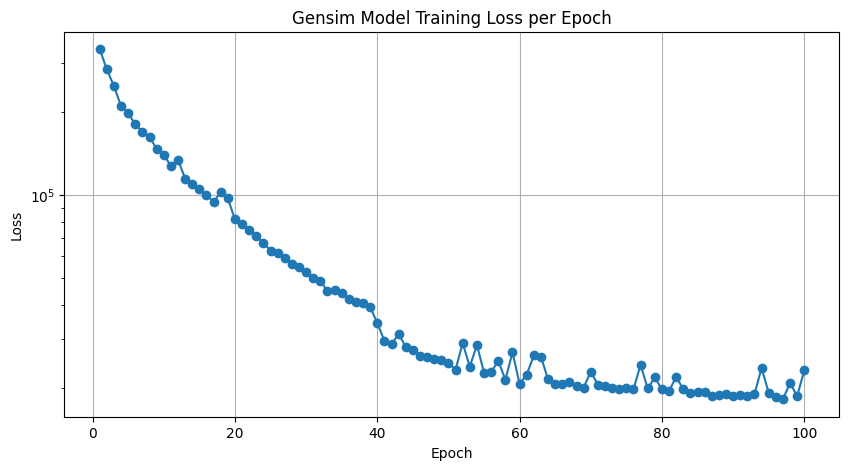

In [68]:
loss_logger = LossLogger()

lbh_model.train(lbh_text, 
                total_examples=lbh_model.corpus_count, 
                epochs=100, 
                compute_loss=True, 
                callbacks=[loss_logger])

plt.figure(figsize=(10, 5))
plt.plot(range(1, len(loss_logger.losses) + 1), loss_logger.losses, marker='o')
plt.title('Gensim Model Training Loss per Epoch')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.yscale('log')
plt.grid(True)
plt.show()

In [69]:
filepath = r'/Users/aaronadair/Downloads/DiachronicEmb-BigHistData-main/cbh.txt'


with open(filepath, 'r', encoding='utf-8') as file:
    lines = file.readlines()

cbh_text = [clean_line(line) for line in lines]
cbh_text = [x for x in cbh_text if x != '']

# texts = [[text for text in doc.split()] for doc in heb_text]

# lbh_text = [clean_line(line) for line in lines]
# lbh_text = lines[0].split(' ')
# lbh_text = [x for x in lbh_text if x != '']

cbh_text = [[text for text in doc.split()] for doc in cbh_text]

Epoch 1: Loss 1320769.125
Epoch 1: Loss 530443.0625
Epoch 2: Loss 456995.25
Epoch 3: Loss 407922.8125
Epoch 4: Loss 350729.375
Epoch 5: Loss 337717.875
Epoch 6: Loss 340562.375
Epoch 7: Loss 316233.75
Epoch 8: Loss 255370.5
Epoch 9: Loss 286155.25


Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'


Epoch 10: Loss 246628.75
Epoch 11: Loss 245574.25
Epoch 12: Loss 242404.75
Epoch 13: Loss 212353.0
Epoch 14: Loss 176022.5
Epoch 15: Loss 172774.0
Epoch 16: Loss 155763.5
Epoch 17: Loss 145682.0
Epoch 18: Loss 150213.0
Epoch 19: Loss 123534.5
Epoch 20: Loss 132220.5
Epoch 21: Loss 126228.5
Epoch 22: Loss 109063.0
Epoch 23: Loss 111265.5
Epoch 24: Loss 110475.0
Epoch 25: Loss 94083.0
Epoch 26: Loss 98540.5
Epoch 27: Loss 100870.0
Epoch 28: Loss 97952.0
Epoch 29: Loss 89677.5
Epoch 30: Loss 88838.5
Epoch 31: Loss 93252.5
Epoch 32: Loss 75328.5
Epoch 33: Loss 89809.5
Epoch 34: Loss 87983.0
Epoch 35: Loss 81719.5
Epoch 36: Loss 86786.0
Epoch 37: Loss 71242.5
Epoch 38: Loss 84835.5
Epoch 39: Loss 84216.0
Epoch 40: Loss 77528.5
Epoch 41: Loss 74705.5
Epoch 42: Loss 68708.5
Epoch 43: Loss 70779.0
Epoch 44: Loss 77772.0
Epoch 45: Loss 79933.0
Epoch 46: Loss 74139.0
Epoch 47: Loss 75989.5
Epoch 48: Loss 82812.0
Epoch 49: Loss 74863.0
Epoch 50: Loss 69124.5
Epoch 51: Loss 73604.0
Epoch 52: Loss 

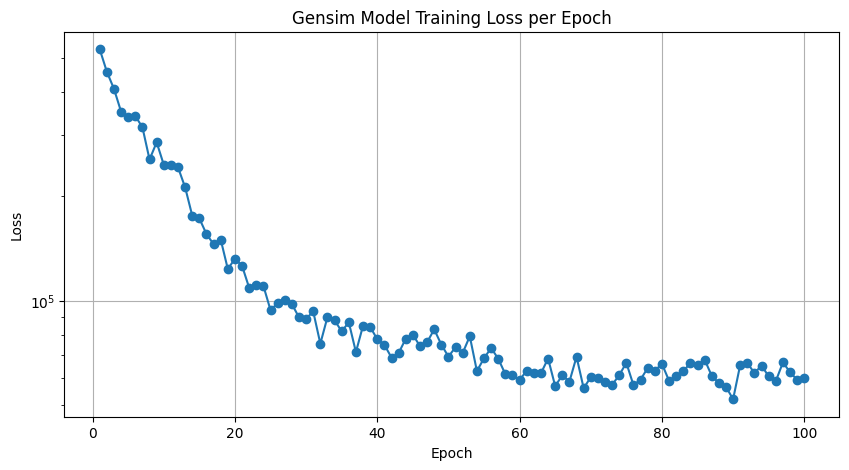

In [70]:
loss_logger = LossLogger()

cbh_model = Word2Vec(
    texts,
    vector_size=1000,  # Dimensionality of the word vectors
    window=15,         # Context window size
    min_count=1,      # Ignore words with frequency less than 1
    sg=1,             # CBOW (0) or Skip-Gram (1)
    workers=8,        # Number of worker threads
    epochs=1,         # Number of training epochs
    compute_loss=True, 
    callbacks=[loss_logger]
)

loss_logger = LossLogger()

cbh_model.train(cbh_text, 
                total_examples=cbh_model.corpus_count, 
                epochs=100, 
                compute_loss=True, 
                callbacks=[loss_logger])

plt.figure(figsize=(10, 5))
plt.plot(range(1, len(loss_logger.losses) + 1), loss_logger.losses, marker='o')
plt.title('Gensim Model Training Loss per Epoch')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.yscale('log')
plt.grid(True)
plt.show()

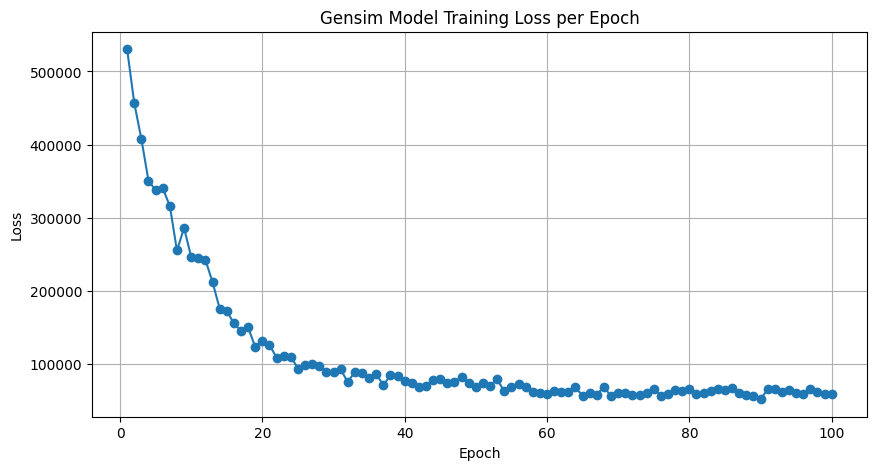

In [71]:
plt.figure(figsize=(10, 5))
plt.plot(range(1, len(loss_logger.losses) + 1), loss_logger.losses, marker='o')
plt.title('Gensim Model Training Loss per Epoch')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.grid(True)
plt.show()

In [72]:
cbh_model.wv[0]

array([ 5.12471676e-01, -2.07941562e-01,  6.32363915e-01,  8.32298517e-01,
       -1.57696828e-01,  1.85983047e-01,  9.23448950e-02,  7.96896577e-01,
       -4.45379525e-01,  2.56473929e-01,  9.42926943e-01, -2.87827194e-01,
        2.04362422e-01,  4.18842614e-01,  5.80743134e-01, -8.66824538e-02,
       -2.92971373e-01,  2.31715843e-01,  3.15264314e-01, -4.95247871e-01,
        6.88280463e-01, -5.90213358e-01,  3.17059904e-01,  4.48426977e-02,
        3.47181410e-02,  3.61396283e-01,  4.75843012e-01,  1.75723404e-01,
       -9.91022348e-01,  3.34841311e-01, -3.43448997e-01,  2.05912411e-01,
       -8.24548900e-01,  1.30113944e-01,  6.50341928e-01, -1.32261924e-02,
        2.34377816e-01,  1.20513968e-01, -1.58217158e-02, -2.71515995e-01,
       -2.85890084e-02,  3.74082774e-02, -2.76768506e-01,  8.09121430e-01,
       -3.30238074e-01, -4.01913114e-02, -3.84878553e-02,  6.81263447e-01,
       -1.07018411e-01, -4.28459831e-02,  1.00399837e-01,  3.93610328e-01,
        3.36884670e-02, -

In [73]:
np.linalg.norm(cbh_model.wv[0] - lbh_model.wv[0])

7.201252

In [74]:
cosine_similarity(cbh_model.wv[0].reshape(1, -1), lbh_model.wv[0].reshape(1, -1))[0][0]

0.5580027

In [75]:
len(lbh_model.wv)

78214

In [77]:
# cosine_similarity(lbh_model.wv['כְּב֥וֹד'].reshape(1, -1), cbh_model.wv['כְּב֥וֹד'].reshape(1, -1))[0][0], \
#     cosine_similarity(cbh_model.wv['כְּב֥וֹד'].reshape(1, -1), lbh_model.wv['כְּב֥וֹד'].reshape(1, -1))[0][0]

# כְּב֥וֹד

In [78]:
diff_list = []

for i in range(len(lbh_model.wv)):
    # diff_val = np.linalg.norm(cbh_model.wv[i] - lbh_model.wv[i])
    diff_val = cosine_similarity(cbh_model.wv[i].reshape(1, -1), lbh_model.wv[i].reshape(1, -1))[0][0]

    # if diff_val > 0.4 and diff_val < 0.7:
    if diff_val < -0.1:
        print(cbh_model.wv.index_to_key[i])

    diff_list.append(diff_val)


40
39
38
37
42
41
48
47
46
45
44
43
50
49
Ecclesiastes
102
88
Psalms
Esther
Song
שְׁכָב
Malachi
Zechariah
וֶאֱלִיעֶֽזֶר׃
Ezra
הַנִּיחָה
בְּרִיבֽוֹ׃
אֽ͏ָנֹכִי
הַנֶּגֶף
וְאֶת־מִגְרְשֵׁיהֶֽן׃
לָקַחְנוּ
כָּל־אֲשֶׁר־צִוָּה
וַאֲחַזְיָה
הָרֶם
הוֹאֶל
אֶת־נַעֲמָן
צַק
הַאֶפֶס
עָרֶֽךָ׃
הַֽעֲלִי־לִֽי׃
בְּנִֽי־דָוִד
וְאֶל־אַבְנֵר
אֽוֹ־יוֹמוֹ
וְהֵיטִב
הַקָּֽלַע׃
לִרְדָפְךָ
כְפַֽעַם־בְּפַעַם
כִּֽי־קָרָאתָ
אֵין־קָדוֹשׁ
אֶת־שֵׁלָתֵךְ
וַעֲבוֹדַת
מִכָּל־גְּבוּלָֽם׃
בַּחֲמָֽת׃
אֶת־תַּדְמֹר
וּבָחַרְתִּי
אֶֽהְיֶה־לָּהּ
יֶהְדֹּֽף׃
לְמַֽעַזְיָהוּ
לְמַגֵּפָֽה׃
הַבַּחֲרוּמִי
וְאֶֽת־יָקְמְעָם
בֶּן־מוּשִׁי
בֶּן־מַחְלִי
בֶּן־יַחַת
וַשְׁנִי
וְהַר־חֶרְמוֹן
וָיָֽפֶת׃
רַחִיקִין
יֻסָּֽד׃
וְהֵיכַל
עַל־מְכוֹנֽוֹ׃
וְכָל־הַנִּשְׁאָר
וְיִבֶן
תֶּאְשָֽׁמוּ׃
נְתַתֶּם
**ב‪
וּפִֽילַגְשִׁי
הַנִּרְצָחָה
עַד־גִּבְעָֽה׃
תֵּֽלְכוּ־בָֽהּ׃
הָיָה־לִי
הַמַּחֲזִיק
הָעֲבֹתִים
אֶת־אִישֵׁךְ
בְּלַחְמֶךָ
אִם־תַּעְצְרֵנִי
לְנַחֵל
נִנְחַל
נֵחָלֵץ
לְהַנִּיחוֹ
אֶצְעָדָה
וַנַּקְרֵב
הַמַּלְקוֹחַ
כָּל־נְקֵבָֽה׃
וּלְאִסַּר
פִּטְרַת
וְיִשְׁמְרֶֽךָ׃
וְע

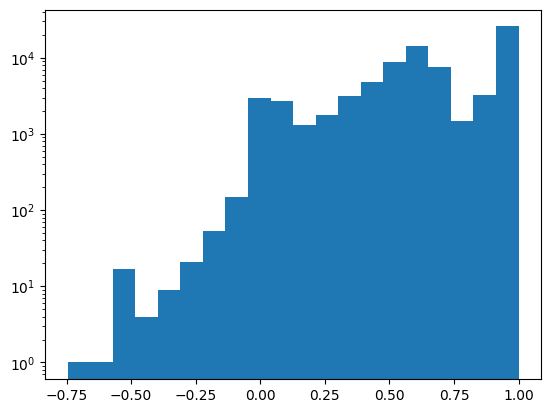

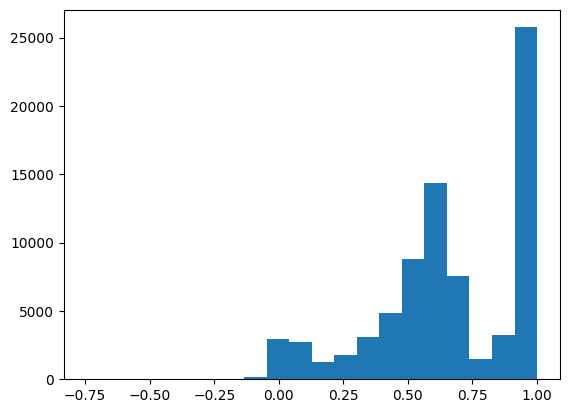

In [79]:
plt.hist(diff_list, bins=20)
plt.yscale('log')
plt.show()
plt.close()

plt.hist(diff_list, bins=20)
plt.show()
plt.close()

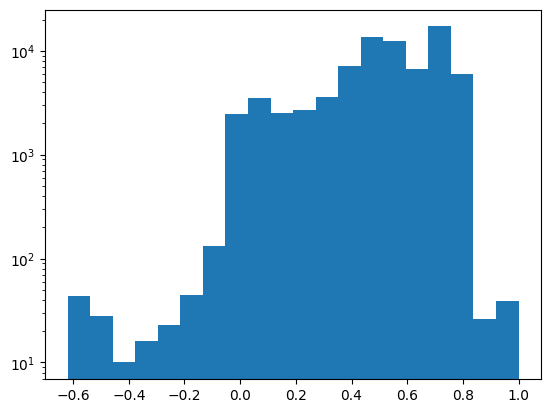

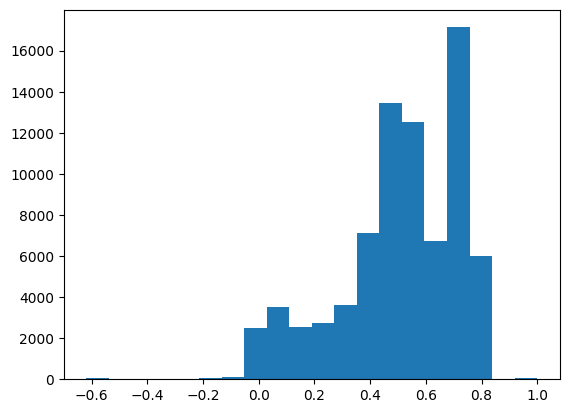

In [80]:
diff_list = []

for i in range(len(lbh_model.wv)):
    # diff_val = np.linalg.norm(cbh_model.wv[i] - lbh_model.wv[i])
    diff_val = cosine_similarity(cbh_model.wv[i].reshape(1, -1), model.wv[i].reshape(1, -1))[0][0]

    # if diff_val > 0.4 and diff_val < 0.7:
    #     print(cbh_model.wv.index_to_key[i])

    diff_list.append(diff_val)

plt.hist(diff_list, bins=20)
plt.yscale('log')
plt.show()
plt.close()

plt.hist(diff_list, bins=20)
plt.show()
plt.close()

0.3596201 יֹדֵעַ יֹדֵעַ True
0.5038502 יֹדֵעַ יֹדְעֵי False
0.38719055 יֹדֵעַ יָדַע False
0.38719055 יֹדֵעַ יָדַע False
0.71167284 יֹדֵעַ יֽוֹדְעִים False
0.2816813 יֹדְעֵי יֹדֵעַ False
0.44637248 יֹדְעֵי יֹדְעֵי True
0.34100613 יֹדְעֵי יָדַע False
0.34100613 יֹדְעֵי יָדַע False
0.6752256 יֹדְעֵי יֽוֹדְעִים False
0.21843372 יָדַע יֹדֵעַ False
0.3988024 יָדַע יֹדְעֵי False
0.3582915 יָדַע יָדַע True
0.3582915 יָדַע יָדַע True
0.6021396 יָדַע יֽוֹדְעִים False
0.21843372 יָדַע יֹדֵעַ False
0.3988024 יָדַע יֹדְעֵי False
0.3582915 יָדַע יָדַע True
0.3582915 יָדַע יָדַע True
0.6021396 יָדַע יֽוֹדְעִים False
0.36439124 יֽוֹדְעִים יֹדֵעַ False
0.53120553 יֽוֹדְעִים יֹדְעֵי False
0.3371194 יֽוֹדְעִים יָדַע False
0.3371194 יֽוֹדְעִים יָדַע False
0.6741395 יֽוֹדְעִים יֽוֹדְעִים True


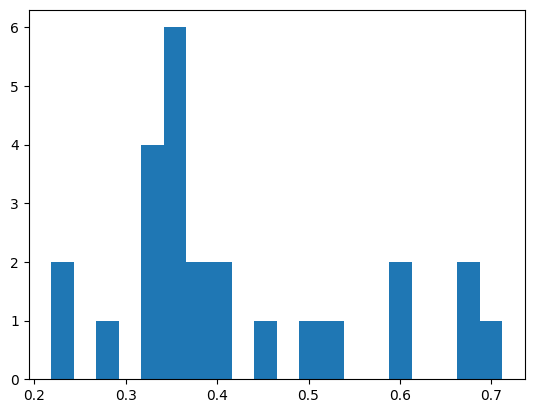

In [83]:
test_word_list = ['יֹדֵ֣עַ', 'יֹדְעֵ֖י', 'יָדַ֖ע', 'יָדַ֣ע', 'יֽוֹדְעִ֗ים']
test_word_list = [clean_line(word) for word in test_word_list]
cos_val_list = []


for test_word in test_word_list:
    for other_word in test_word_list:
        cos_val_list.append(cosine_similarity(lbh_model.wv[test_word].reshape(1, -1), cbh_model.wv[other_word].reshape(1, -1))[0][0])
        print(cos_val_list[-1], test_word, other_word, other_word == test_word)

plt.hist(cos_val_list, bins=20)
plt.show()
plt.close()

In [84]:
cbh_model.wv.index_to_key[1000]

'אוֹתִי'

In [85]:
vector_list = []

for i in range(0, 10000):
    vector_list.append(cbh_model.wv[i])


In [86]:
len(vector_list)

10000

In [87]:
temp_df = pd.DataFrame(vector_list)

In [88]:
cosine_sim_matrix = cosine_similarity(temp_df.T)

(array([  3110.,  28572., 101314., 240704., 334712., 197542.,  73684.,
         18236.,   1126.,   1000.]),
 array([-0.77350044, -0.59615003, -0.41879961, -0.2414492 , -0.06409879,
         0.11325163,  0.29060204,  0.46795245,  0.64530287,  0.82265328,
         1.0000037 ]),
 <BarContainer object of 10 artists>)

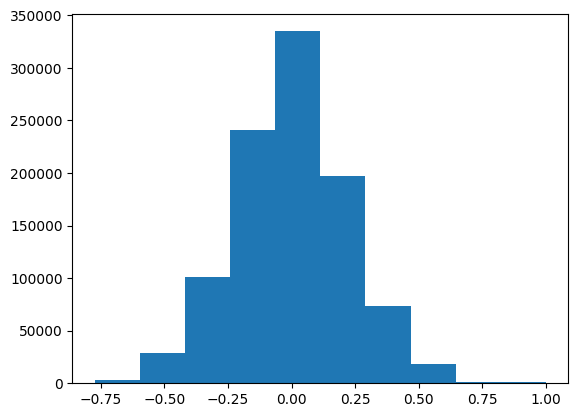

In [89]:
plt.hist(pd.DataFrame(cosine_sim_matrix).values.flatten().tolist())

## How Stable?

In [90]:
diff_list = []

for rand_seed in tqdm(range(0, 50)):
    lbh_new_model = Word2Vec(
        texts,
        vector_size=1000,  # Dimensionality of the word vectors
        window=15,         # Context window size
        min_count=1,      # Ignore words with frequency less than 1
        sg=1,             # CBOW (0) or Skip-Gram (1)
        workers=8,        # Number of worker threads
        epochs=1,         # Number of training epochs
        seed = rand_seed, 
        # compute_loss=True, 
        # callbacks=[loss_logger], 
    )

    lbh_new_model.train(cbh_text, 
                    total_examples=lbh_new_model.corpus_count, 
                    epochs=100, 
                    # compute_loss=True, 
                    # callbacks=[loss_logger], 
                    )

    for i in range(len(lbh_model.wv)):
        diff_val = cosine_similarity(lbh_new_model.wv[i].reshape(1, -1), lbh_model.wv[i].reshape(1, -1))[0][0]
        diff_list.append(diff_val)

  0%|          | 0/50 [00:00<?, ?it/s]Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
  2%|▏         | 1/50 [01:52<1:31:53, 112.51s/it]Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
  4%|▍         | 2/50 [04:13<1:43:16, 129.08s/it]Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
  6%|▌         | 3/50 [05:53<1:30:43, 115.83s/it]Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
  8%|▊     

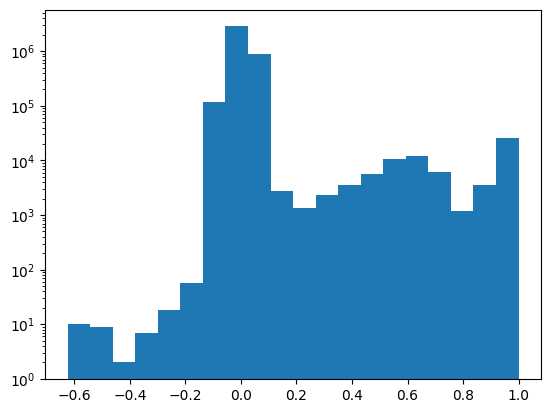

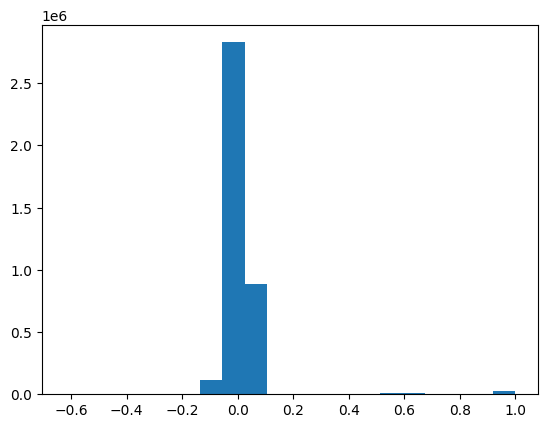

In [91]:
plt.hist(diff_list, bins=20)
plt.yscale('log')
plt.show()
plt.close()

plt.hist(diff_list, bins=20)
plt.show()
plt.close()

In [92]:
from scipy.spatial import procrustes
from scipy.linalg import orthogonal_procrustes

In [93]:
a = np.array([[1, 3], [1, 2], [1, 1], [2, 1]], 'd')
b = np.array([[4, -2], [4, -4], [4, -6], [2, -6]], 'd')
mtx1, mtx2, disparity = procrustes(a, b)

In [94]:
A0 = a - a.mean(axis=0, keepdims=True)
B0 = b - b.mean(axis=0, keepdims=True)

Q, scale = orthogonal_procrustes(A0, B0)

In [95]:
scale

7.0

In [96]:
A0@Q

array([[ 0.25,  1.25],
       [ 0.25,  0.25],
       [ 0.25, -0.75],
       [-0.75, -0.75]])

In [97]:
B0

array([[ 0.5,  2.5],
       [ 0.5,  0.5],
       [ 0.5, -1.5],
       [-1.5, -1.5]])

In [98]:
scale

7.0

In [99]:
lbh_list = []
lbh_new_list = []

for i in range(len(lbh_model.wv)):
    lbh_list.append(lbh_model.wv[i])
    lbh_new_list.append(lbh_new_model.wv[i])

In [100]:
Q, scale = orthogonal_procrustes(lbh_new_list, lbh_list)

In [101]:
lbh_new_rot_list = lbh_new_list@Q

In [102]:
rot_diff_list = []
old_diff_list = []

for i in range(len(lbh_model.wv)):
        diff_val = cosine_similarity(lbh_new_rot_list[i].reshape(1, -1), lbh_list[i].reshape(1, -1))[0][0]
        rot_diff_list.append(diff_val)
        diff_val = cosine_similarity(lbh_new_model.wv[i].reshape(1, -1), lbh_model.wv[i].reshape(1, -1))[0][0]
        old_diff_list.append(diff_val)

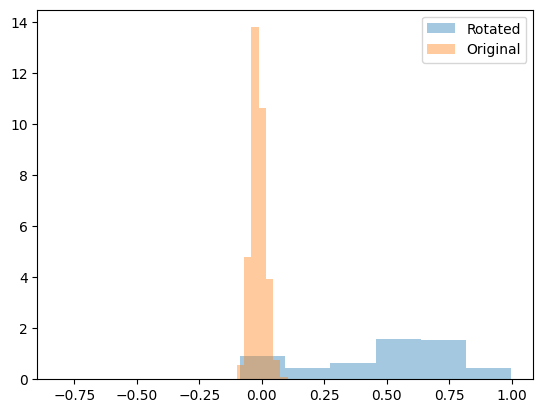

In [103]:
plt.hist(rot_diff_list, alpha=0.4, density=True, label='Rotated')
plt.hist(old_diff_list, alpha=0.4, density=True, label='Original')
plt.legend()
plt.show()
plt.close()